## 1. Import Library

In [1]:
import pandas as pd
import math
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F

## 2. Import Dataset

In [2]:
data_risk = pd.read_csv('credit_risk_dataset.csv')
data_risk

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4
...,...,...,...,...,...,...,...,...,...,...,...,...
32576,57,53000,MORTGAGE,1.0,PERSONAL,C,5800,13.16,0,0.11,N,30
32577,54,120000,MORTGAGE,4.0,PERSONAL,A,17625,7.49,0,0.15,N,19
32578,65,76000,RENT,3.0,HOMEIMPROVEMENT,B,35000,10.99,1,0.46,N,28
32579,56,150000,MORTGAGE,5.0,PERSONAL,B,15000,11.48,0,0.10,N,26


## 3. Exploratory Data Analysis (EDA)

### a. Check Missing Value

In [3]:
data_risk.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

### b. Check Data Information

In [4]:
data_risk.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


### c. Check Data Description

In [5]:
data_risk.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


### d. Dataset Visualization

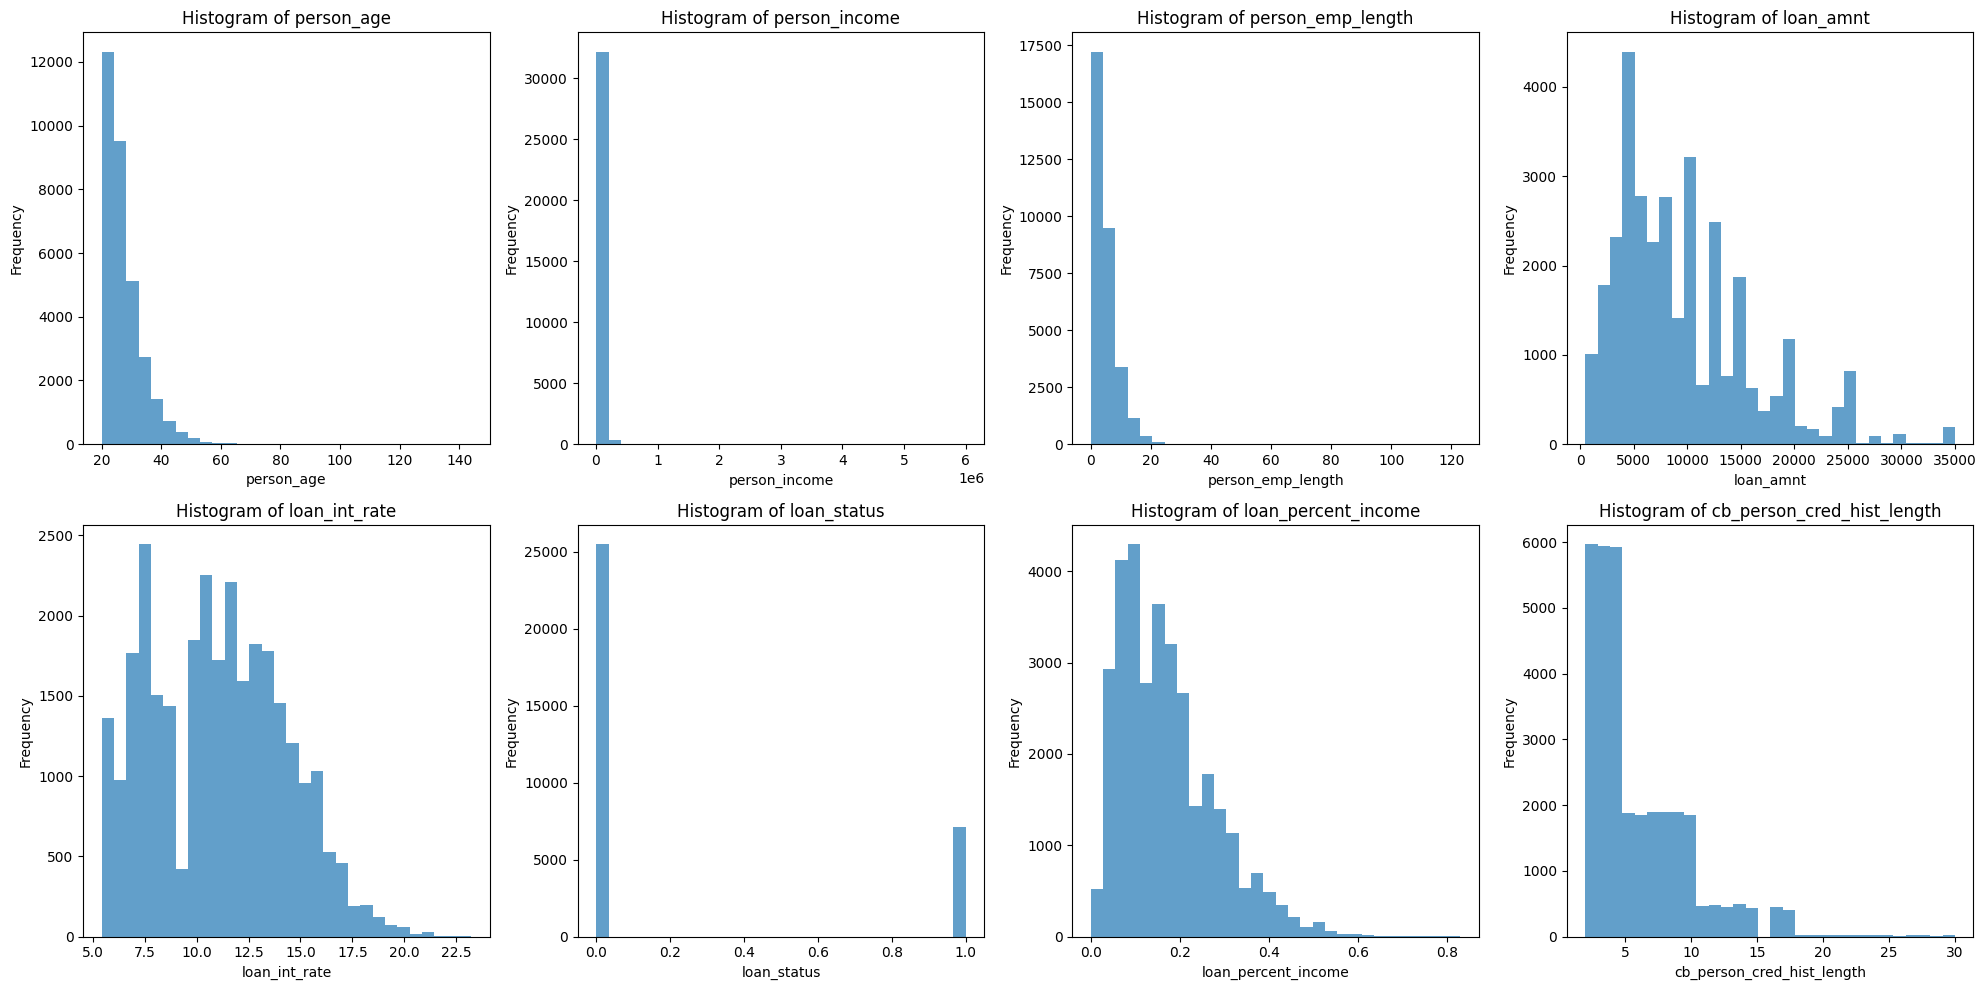

In [6]:
cols = data_risk.select_dtypes(include='number').columns

n_cols = 4
n_rows = math.ceil(len(cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5*n_rows))
axes = axes.flatten()

for i, item in enumerate(cols):
    axes[i].hist(data_risk[item].dropna(), bins=30, alpha=0.7)
    axes[i].set_title(f'Histogram of {item}')
    axes[i].set_xlabel(item)
    axes[i].set_ylabel('Frequency')

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## 4. Preprocessing

### a. Encoding the Column

In [7]:
from sklearn.preprocessing import OneHotEncoder

encoder_home = OneHotEncoder(sparse_output=False)
encoder_intent = OneHotEncoder(sparse_output=False)

X_home = encoder_home.fit_transform(
    data_risk[["person_home_ownership"]]
)

X_intent = encoder_intent.fit_transform(
    data_risk[["loan_intent"]]
)

In [8]:
home_cols = encoder_home.get_feature_names_out(
    ["person_home_ownership"]
)

intent_cols = encoder_intent.get_feature_names_out(
    ["loan_intent"]
)

df_home = pd.DataFrame(X_home, columns=home_cols, index=data_risk.index)
df_intent = pd.DataFrame(X_intent, columns=intent_cols, index=data_risk.index)

In [9]:
data_risk_encode = pd.concat(
    [data_risk, df_home, df_intent],
    axis=1
)

In [10]:
data_risk_encode.drop(
    ["person_home_ownership", "loan_intent"],
    axis=1,
    inplace=True
)

In [11]:
data_risk_encode["loan_grade"] = (
    data_risk_encode["loan_grade"]
    .astype(str)
    .str.strip()
    .str.upper()
)

grade_map = {
    "A": 0,
    "B": 1,
    "C": 2,
    "D": 3,
    "E": 4,
    "F": 5,
    "G": 6,
}

data_risk_encode["loan_grade"] = data_risk_encode["loan_grade"].map(grade_map)

In [12]:
person_default_map = {
    "Y": 1,
    "N": 0
}

data_risk_encode["cb_person_default_on_file"] = data_risk_encode["cb_person_default_on_file"].map(person_default_map)

In [13]:
data_risk_encode

,person_age,person_income,person_emp_length,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,person_home_ownership_MORTGAGE,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_DEBTCONSOLIDATION,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE
0,22,59000,123.0,3,35000,16.02,1,0.59,1,3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1,21,9600,5.0,1,1000,11.14,0,0.10,0,2,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,25,9600,1.0,2,5500,12.87,1,0.57,0,3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,23,65500,4.0,2,35000,15.23,1,0.53,0,2,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
4,24,54400,8.0,2,35000,14.27,1,0.55,1,4,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32576,57,53000,1.0,2,5800,13.16,0,0.11,0,30,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
32577,54,120000,4.0,0,17625,7.49,0,0.15,0,19,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
32578,65,76000,3.0,1,35000,10.99,1,0.46,0,28,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
32579,56,150000,5.0,1,15000,11.48,0,0.10,0,26,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


### b. Fill in Blank Data

In [14]:
data_risk_encode.isnull().sum()

person_age                           0
person_income                        0
person_emp_length                  895
loan_grade                           0
loan_amnt                            0
loan_int_rate                     3116
loan_status                          0
loan_percent_income                  0
cb_person_default_on_file            0
cb_person_cred_hist_length           0
person_home_ownership_MORTGAGE       0
person_home_ownership_OTHER          0
person_home_ownership_OWN            0
person_home_ownership_RENT           0
loan_intent_DEBTCONSOLIDATION        0
loan_intent_EDUCATION                0
loan_intent_HOMEIMPROVEMENT          0
loan_intent_MEDICAL                  0
loan_intent_PERSONAL                 0
loan_intent_VENTURE                  0
dtype: int64

In [15]:
data_median = ["person_emp_length","loan_int_rate"]
for data in data_median:
    data_risk_encode[data] = data_risk_encode[data].fillna(data_risk_encode[data].median())

In [16]:
data_risk_encode.isnull().sum()

person_age                        0
person_income                     0
person_emp_length                 0
loan_grade                        0
loan_amnt                         0
loan_int_rate                     0
loan_status                       0
loan_percent_income               0
cb_person_default_on_file         0
cb_person_cred_hist_length        0
person_home_ownership_MORTGAGE    0
person_home_ownership_OTHER       0
person_home_ownership_OWN         0
person_home_ownership_RENT        0
loan_intent_DEBTCONSOLIDATION     0
loan_intent_EDUCATION             0
loan_intent_HOMEIMPROVEMENT       0
loan_intent_MEDICAL               0
loan_intent_PERSONAL              0
loan_intent_VENTURE               0
dtype: int64

### c. Split Dataset

In [17]:
X = data_risk_encode.drop(["loan_status"], axis=1)
y = data_risk_encode["loan_status"]

### d. Normalization Dataset

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=41)

In [19]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns, 
    index=X_train.index     
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

## 5. Modelling

### a. Set the Criterion of Model and Optimizer

In [20]:
def _(model, nn, torch):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr = 0.01)
    return criterion, optimizer

### b. Make Model

In [21]:
class Model(nn.Module):
    def __init__(self, in_features=19,h1=12, h2=24, out_features=2):
        super().__init__()
        self.fc1 = nn.Linear(in_features, h1)
        self.fc2 = nn.Linear(h1, h2)
        self.out = nn.Linear(h2, out_features)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.out(x)

        return x

In [22]:
torch.manual_seed(41)
model = Model()

In [23]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr = 0.01)

### c. Train Model

In [24]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

In [25]:
X_train_tensor = torch.tensor(X_train_scaled.values, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled.values, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train_encoded, dtype=torch.long)
y_test_tensor = torch.tensor(y_test_encoded, dtype=torch.long)

In [26]:
epochs = 500
losses = []

for attribute in range(epochs):
    # Go forward
    y_pred = model.forward(X_train_tensor)

    # Measure the loss
    loss = criterion(y_pred, y_train_tensor)

    # Keep track
    losses.append(loss.detach().numpy())

    # Print every 10 seconds
    # Ganti baris print loss dengan ini:
    if attribute % 10 == 0:
        print(f'Epoch: {attribute} \t Loss: {loss.item():.4f}')

    # Back propagation 
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

Epoch: 0 	 Loss: 0.6801
Epoch: 10 	 Loss: 0.4524
Epoch: 20 	 Loss: 0.3779
Epoch: 30 	 Loss: 0.3448
Epoch: 40 	 Loss: 0.3209
Epoch: 50 	 Loss: 0.3067
Epoch: 60 	 Loss: 0.2943
Epoch: 70 	 Loss: 0.2846
Epoch: 80 	 Loss: 0.2774
Epoch: 90 	 Loss: 0.2701
Epoch: 100 	 Loss: 0.2636
Epoch: 110 	 Loss: 0.2574
Epoch: 120 	 Loss: 0.2523
Epoch: 130 	 Loss: 0.2481
Epoch: 140 	 Loss: 0.2442
Epoch: 150 	 Loss: 0.2407
Epoch: 160 	 Loss: 0.2374
Epoch: 170 	 Loss: 0.2345
Epoch: 180 	 Loss: 0.2329
Epoch: 190 	 Loss: 0.2300
Epoch: 200 	 Loss: 0.2277
Epoch: 210 	 Loss: 0.2252
Epoch: 220 	 Loss: 0.2235
Epoch: 230 	 Loss: 0.2226
Epoch: 240 	 Loss: 0.2214
Epoch: 250 	 Loss: 0.2204
Epoch: 260 	 Loss: 0.2195
Epoch: 270 	 Loss: 0.2186
Epoch: 280 	 Loss: 0.2179
Epoch: 290 	 Loss: 0.2173
Epoch: 300 	 Loss: 0.2175
Epoch: 310 	 Loss: 0.2165
Epoch: 320 	 Loss: 0.2161
Epoch: 330 	 Loss: 0.2156
Epoch: 340 	 Loss: 0.2153
Epoch: 350 	 Loss: 0.2150
Epoch: 360 	 Loss: 0.2147
Epoch: 370 	 Loss: 0.2147
Epoch: 380 	 Loss: 0.21

## 6. Plot the Model

Text(0.5, 0, 'Epoch')

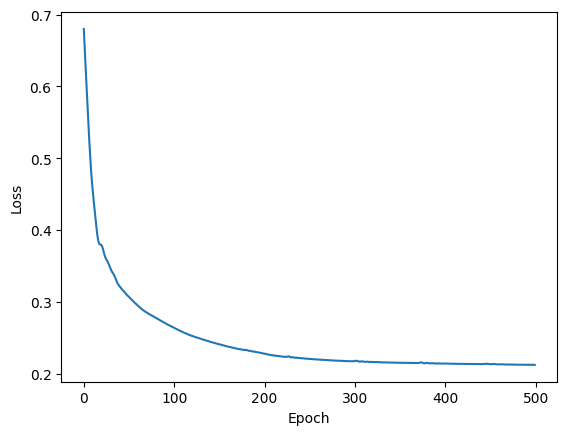

In [27]:
plt.plot(range(epochs), losses)
plt.ylabel("Loss")
plt.xlabel("Epoch")

## 7. Test the Model

In [28]:
with torch.no_grad():
    y_eval = model.forward(X_test_tensor)
    loss_model = criterion(y_eval, y_test_tensor)

In [29]:
loss_model

tensor(0.2369)

In [30]:
correct = 0
total = 0
with torch.no_grad():
     for x, datas in enumerate(X_test_tensor):
        y_val_test = model.forward(datas)
        if y_val_test.argmax().item() == y_test_tensor[x]:
            correct += 1
        total += 1

print(f'\nKesimpulan Evaluasi:')
print(f'Jumlah Data Tes: {total}')
print(f'Prediksi Benar : {correct}')
print(f'Akurasi Model  : {correct/total * 100:.2f}%')


Kesimpulan Evaluasi:
Jumlah Data Tes: 6517
Prediksi Benar : 5997
Akurasi Model  : 92.02%
